In [48]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

## DATA LOADING & CLEANING

In [49]:
def load_logs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.json_normalize(data)

baseline_df = load_logs('../../data/history/baseline_architecture_log.json')
spear_df = load_logs('../../data/history/spear_architecture_log.json')
df = pd.concat([baseline_df, spear_df], ignore_index=True)


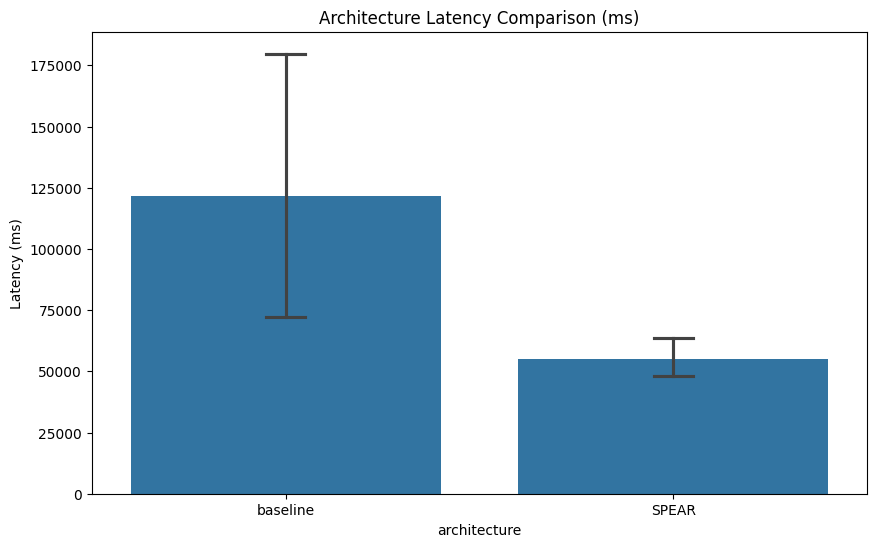

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='latency_ms', data=df, capsize=.1)
plt.title('Architecture Latency Comparison (ms)')
plt.ylabel('Latency (ms)')
plt.show()


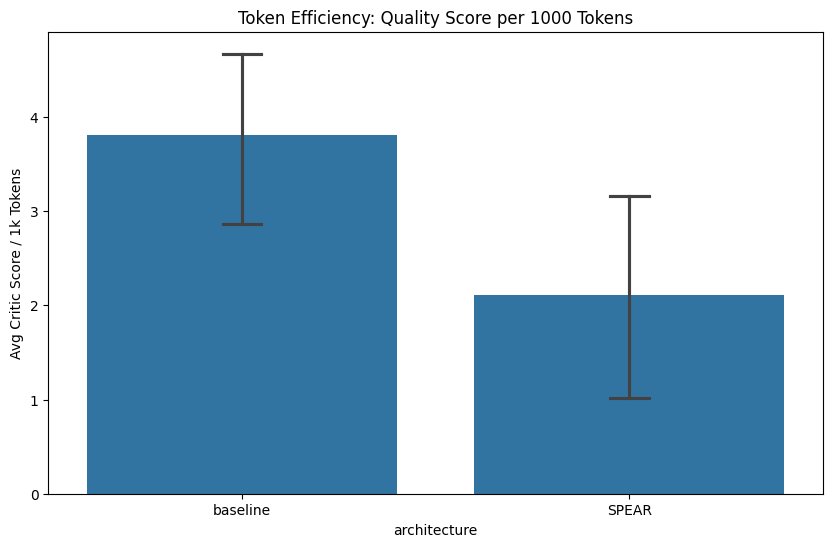

In [51]:
critic_cols = [
    'async_critic_scores.rule_accuracy', 
    'async_critic_scores.narrative_coherence', 
    'async_critic_scores.npc_voice_consistency'
]
df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['total_critic_score'] = df[critic_cols].sum(axis=1)
df['score_per_1k_tokens'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='score_per_1k_tokens', data=df, capsize=.1)
plt.title('Token Efficiency: Quality Score per 1000 Tokens')
plt.ylabel('Avg Critic Score / 1k Tokens')
plt.show()

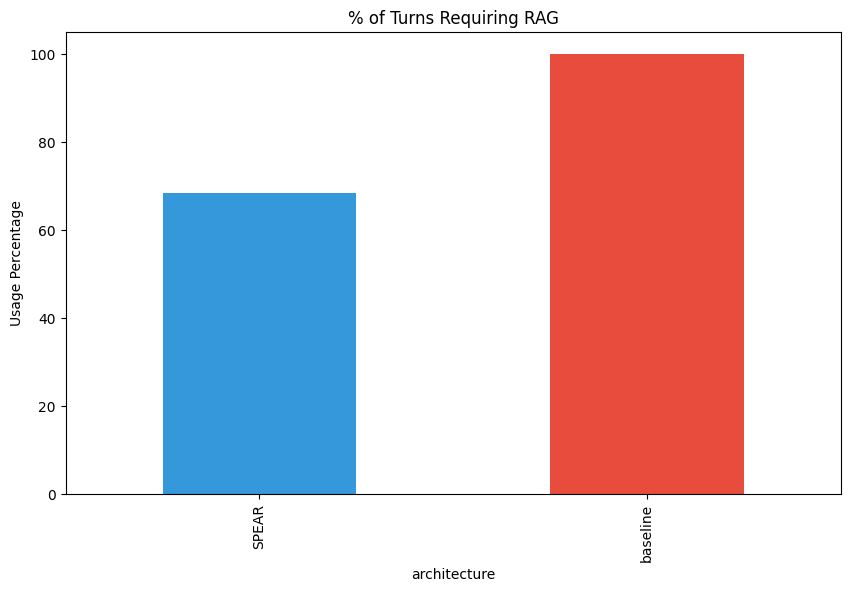

In [52]:
plt.figure(figsize=(10, 6))
rag_usage = df.groupby('architecture')['retrieval_types.rag_vector'].mean() * 100
rag_usage.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('% of Turns Requiring RAG')
plt.ylabel('Usage Percentage')
plt.show()

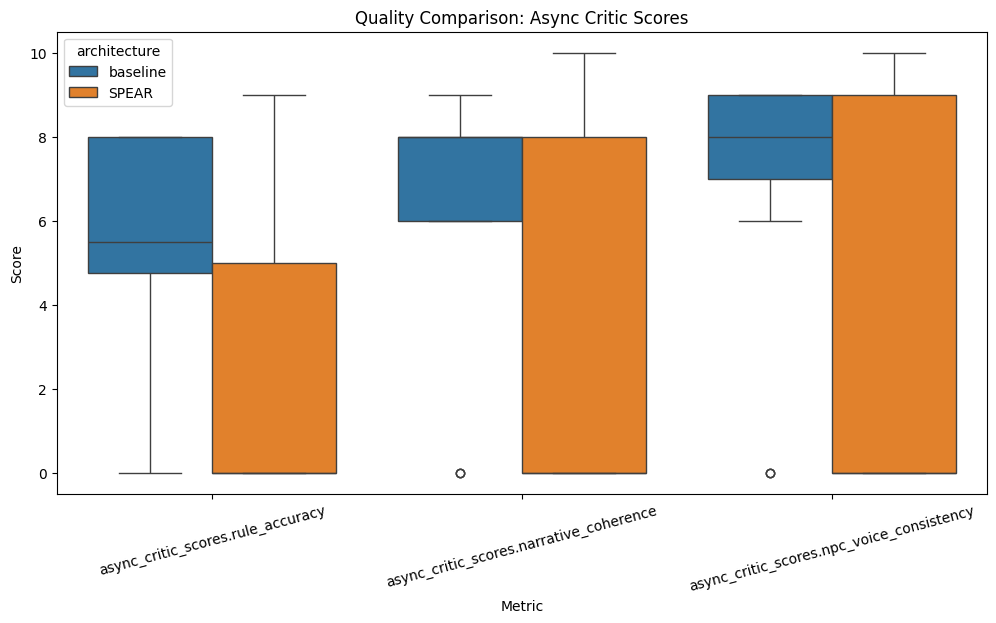

In [53]:
critic_cols = [
    'async_critic_scores.rule_accuracy', 
    'async_critic_scores.narrative_coherence', 
    'async_critic_scores.npc_voice_consistency'
]

# Standardize scores (Handling 0s or NaNs)
melted_df = df.melt(id_vars=['architecture'], value_vars=critic_cols, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Metric', y='Score', hue='architecture', data=melted_df)
plt.title('Quality Comparison: Async Critic Scores')
plt.xticks(rotation=15)
plt.show()

In [54]:
hallucination_rate = spear_df['routing_hallucination'].mean() * 100
print(f"SPEAR Routing Hallucination Rate: {hallucination_rate:.2f}%")

SPEAR Routing Hallucination Rate: 0.00%


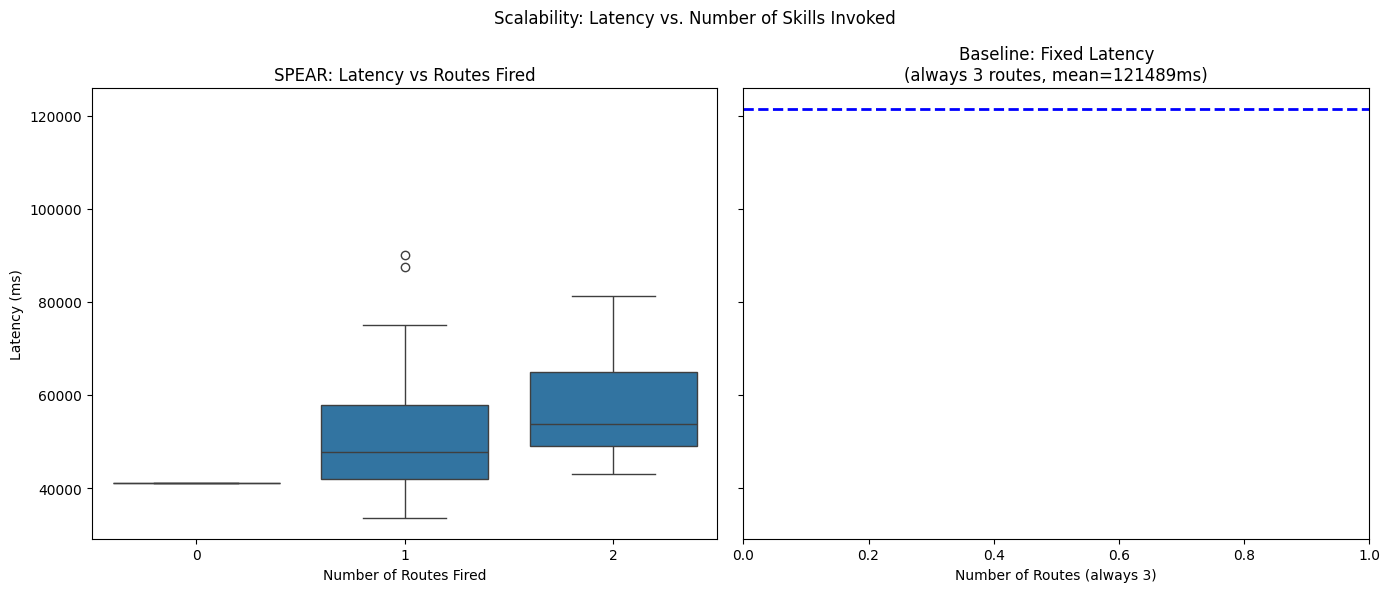

In [55]:
# Compute BEFORE filtering
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Filter AFTER num_routes exists
spear_data = df[df['architecture'] == 'SPEAR']

sns.boxplot(x='num_routes', y='latency_ms', data=spear_data, ax=axes[0])
axes[0].set_title('SPEAR: Latency vs Routes Fired')
axes[0].set_xlabel('Number of Routes Fired')
axes[0].set_ylabel('Latency (ms)')

baseline_mean = df[df['architecture'] == 'baseline']['latency_ms'].mean()
axes[1].axhline(y=baseline_mean, color='blue', linestyle='--', linewidth=2)
axes[1].set_title(f'Baseline: Fixed Latency\n(always 3 routes, mean={baseline_mean:.0f}ms)')
axes[1].set_xlabel('Number of Routes (always 3)')

plt.suptitle('Scalability: Latency vs. Number of Skills Invoked')
plt.tight_layout()
plt.show()

In [56]:
# 1. Standardize the columns
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

# 2. Corrected Sparsity Calculation
spear_mask = df['architecture'] == 'SPEAR'
spear_data = df[spear_mask]

if len(spear_data) > 0:
    total_possible_slots = len(spear_data) * 3
    total_actual_slots = spear_data['num_routes'].sum()
    sparsity_val = (1 - (total_actual_slots / total_possible_slots)) * 100

    # THE FIX: Added the 'f' prefix to the string below
    print(f"SPEAR Skill Sparsity: {sparsity_val:.2f}%")
    print(f"Interpretation: SPEAR successfully avoided loading unneeded skills in {sparsity_val:.2f}% of potential cases.")
else:
    print("Error: No SPEAR logs found in the dataframe.")

SPEAR Skill Sparsity: 59.65%
Interpretation: SPEAR successfully avoided loading unneeded skills in 59.65% of potential cases.


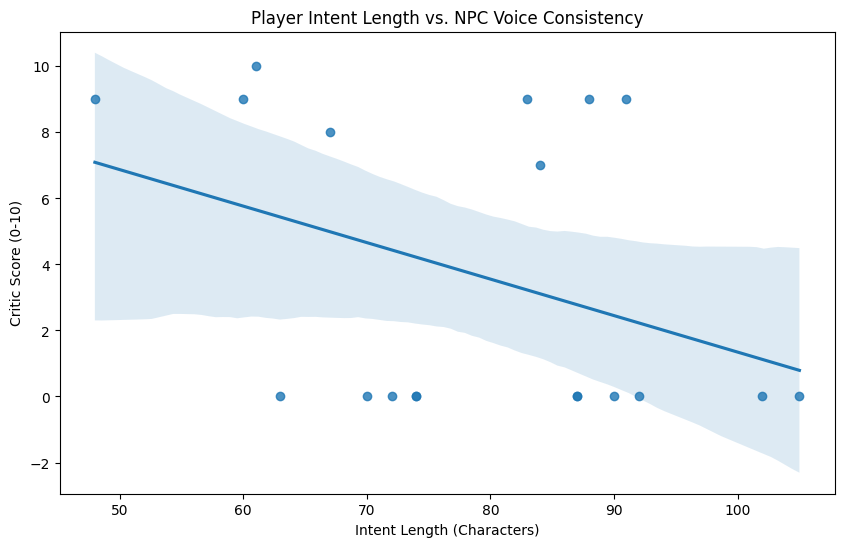

In [57]:
df['intent_length'] = df['player_intent'].str.len()

plt.figure(figsize=(10, 6))
sns.regplot(
    x='intent_length', 
    y='async_critic_scores.npc_voice_consistency', 
    data=df[df['architecture'] == 'SPEAR']
)
plt.title('Player Intent Length vs. NPC Voice Consistency')
plt.xlabel('Intent Length (Characters)')
plt.ylabel('Critic Score (0-10)')
plt.show()

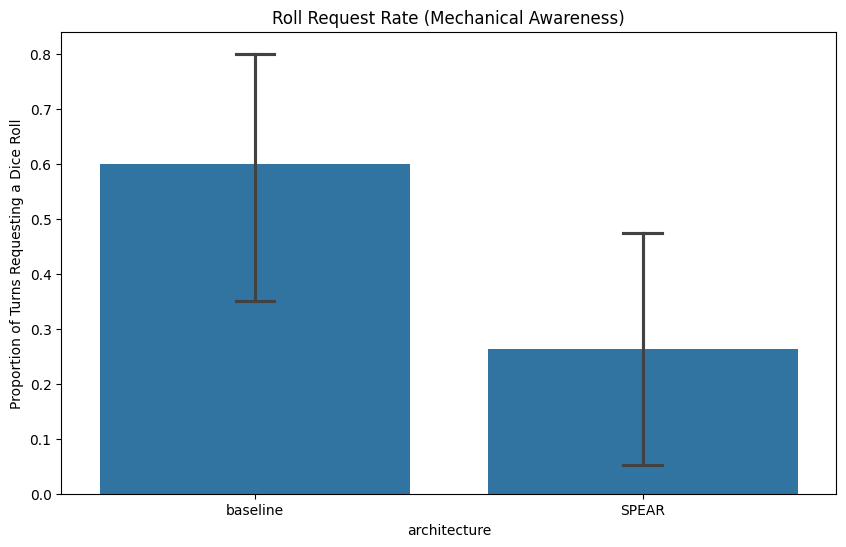

In [58]:
df['requested_roll'] = df['final_output.pending_action.skill'].notna().astype(int)

plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='requested_roll', data=df, capsize=.1)
plt.title('Roll Request Rate (Mechanical Awareness)')
plt.ylabel('Proportion of Turns Requesting a Dice Roll')
plt.show()

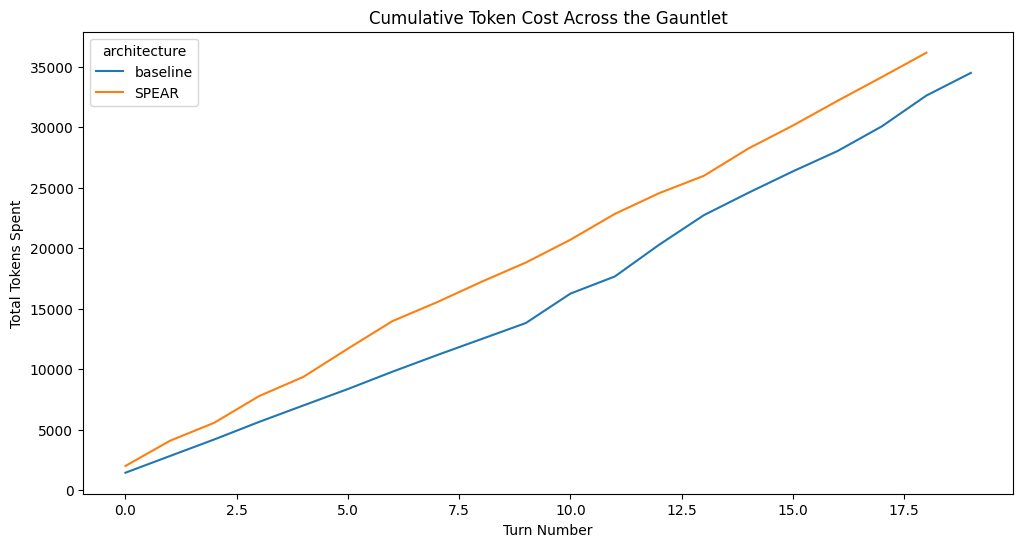

In [59]:
df_sorted = df.sort_values('timestamp_utc')
df_sorted['cumulative_tokens'] = df_sorted.groupby('architecture')['total_tokens'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=df_sorted.groupby('architecture').cumcount(), 
             y='cumulative_tokens', 
             hue='architecture', 
             data=df_sorted)
plt.title('Cumulative Token Cost Across the Gauntlet')
plt.xlabel('Turn Number')
plt.ylabel('Total Tokens Spent')
plt.show()

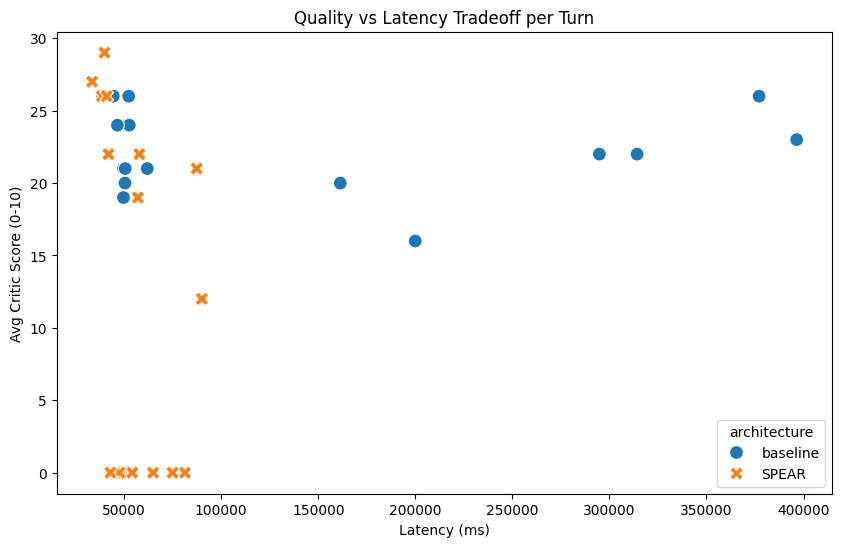

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='latency_ms', 
    y='total_critic_score',
    hue='architecture',
    style='architecture',
    s=100,
    data=df
)
plt.title('Quality vs Latency Tradeoff per Turn')
plt.xlabel('Latency (ms)')
plt.ylabel('Avg Critic Score (0-10)')
plt.show()

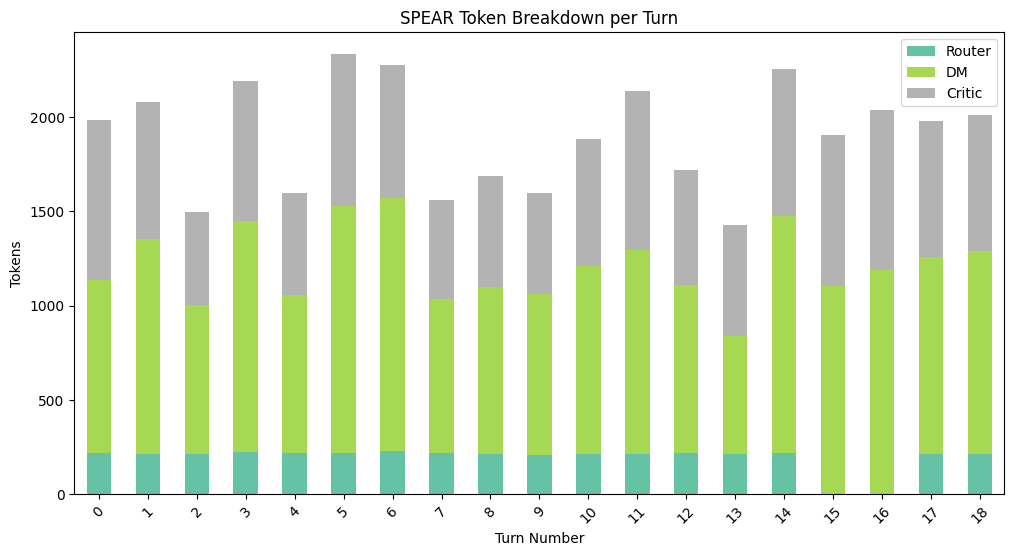

In [61]:
spear_df = df[df['architecture'] == 'SPEAR'].copy()

token_components = pd.DataFrame({
    'Router':  spear_df['token_breakdown.router'].values,
    'DM':      spear_df['token_breakdown.dm'].values,
    'Critic':  spear_df['token_breakdown.critic'].values,
})

token_components.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('SPEAR Token Breakdown per Turn')
plt.xlabel('Turn Number')
plt.ylabel('Tokens')
plt.xticks(rotation=45)
plt.show()

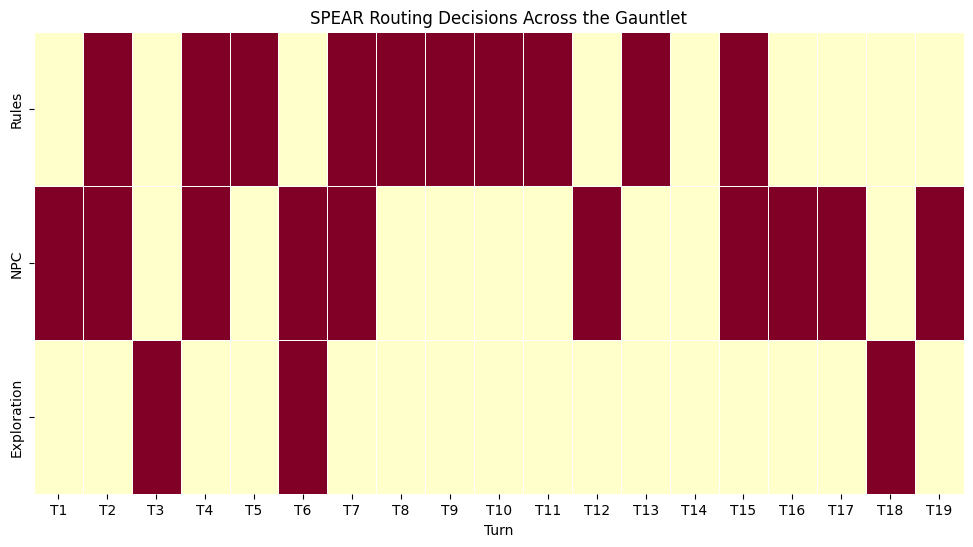

In [62]:
route_cols = ['routes_fired.rules_logic', 'routes_fired.npc_lore', 'routes_fired.world_exploration']
spear_routes = df[df['architecture'] == 'SPEAR'][route_cols].astype(int)
spear_routes.columns = ['Rules', 'NPC', 'Exploration']

plt.figure(figsize=(12, 6))
sns.heatmap(
    spear_routes.T, 
    cmap='YlOrRd', 
    cbar=False,
    linewidths=0.5,
    yticklabels=['Rules', 'NPC', 'Exploration'],
    xticklabels=[f"T{i+1}" for i in range(len(spear_routes))]
)
plt.title('SPEAR Routing Decisions Across the Gauntlet')
plt.xlabel('Turn')
plt.show()